In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [156]:
import polars as pl
import altair as alt

# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS
from statsforecast.adapters.prophet import AutoARIMAProphet
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP, NHITS, BiTCN, RNN
from neuralforecast.auto import AutoNHITS
from neuralforecast.losses.pytorch import DistributionLoss, MAE
from coreforecast.scalers import boxcox, inv_boxcox, boxcox_lambda
from typing import Callable, Literal, Any, Mapping, Optional, Iterable

# import calendar
from utilsforecast.plotting import plot_series as plot_series_utils
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics

# from scipy.stats import pearsonr
# from plotly import express as px
# from pathlib import Path
# from itertools import chain
from typing import Optional

import importlib
import lib
import read_data

importlib.reload(lib)

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

polars.config.Config

In [4]:
def make_timeseries(
    df: pl.DataFrame,
    y: str,
    ds: str = "Date_depot",
    blambda: float = 1,
) -> pl.DataFrame:
    return df.select(
        ds=ds,
        y=pl.col(y).map_batches(lambda s: boxcox(s.to_numpy(), blambda)),
        unique_id=pl.lit("all"),
    )

In [5]:
def complete_operations(
    df: pl.DataFrame,
    starting_states: list = ["depot"],
    end_states: list = ["liv"],
) -> pl.DataFrame:
    return (
        df
        .filter(
            pl.col("status_code").first().over("id").is_in(starting_states),
            pl.col("status_code").last().over("id").is_in(end_states),
        )
    )

In [120]:
gregorian_year_days = int(365.25)
gregorian_year_weeks = int(gregorian_year_days / 7)
hijri_year_days = int(354.37)
hijri_year_weeks = int(hijri_year_days / 7)

In [7]:
cabs_inter = set(read_data.read_smi_envoisbyproduitintern_many()["codeenvoi_"])

In [8]:
fields = (
    pl.read_parquet("data/cab_dfs/fields.parquet")
    .filter(Etat="V")
    .filter(pl.col("Cab").is_in(cabs_inter))
    .filter(pl.col("Date_depot").ge(pl.date(2023, 1, 1)))
    .cast({"Id": pl.String})
    .sort("Date_depot")
    .rename({"Poids_global_en_KG": "weight_kg"})
    .drop_nulls("weight_kg")
)

# operations = (
#     pl.read_parquet("data/cab_dfs/operations.parquet")
#     .filter(pl.col("cab").is_in(cabs_inter))
#     .filter(is_valid="V")
# )

In [ ]:
def make_hist_cols(
    value_col: str,
    bins: list[float],
    agg_method: Literal["sum", "len"] = "sum",
    separator: str = "_",
    prefix: str | None = None,
):
    prefix = prefix or value_col

    return [
        (
            pl.col(value_col)
            .is_between(lo, hi, closed="left")
            .sum()
            .alias(f"{prefix}{separator}{agg_method}{separator}{i}")
        )
        for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:]))
    ]

In [108]:
fields.select(pl.col("Date_depot"), pl.len().over("Date_depot"))

Date_depot,len
date,u32
2023-01-02,333
2023-01-02,333
2023-01-02,333
2023-01-02,333
2023-01-02,333
…,…
2026-05-18,147
2026-05-18,147
2026-05-18,147


In [ ]:
(
    fields.pipe(
        lib.aggregate_by_date,
        freq="7d",
        value_col="weight_kg",
        date_col="Date_depot",
        total_col="total_weight",
        mean_col="mean_weight",
        std_col="std_weight",
        # extra_cols=[
        #     pl.col("weight_kg").hist().list.to_struct(upper_bound=10).alias("weight_hist"),
        # ],
    )
    .unnest("weight_hist")
)

Date_depot,total_weight,count,mean_weight,std_weight
date,f64,u32,f64,f64
2022-12-29,4305.105,799,5.388116,6.112014
2023-01-05,5867.87,1097,5.349015,6.097953
2023-01-12,7237.068,1447,5.001429,5.76774
2023-01-19,6498.301,1215,5.348396,5.766103
2023-01-26,6455.271,1243,5.193299,5.859815
…,…,…,…,…
2026-04-16,3243.537,559,5.802392,6.980324
2026-04-23,3486.82,529,6.591342,7.92391
2026-04-30,2846.966,529,5.381788,6.501721


In [61]:
importlib.reload(lib)
base_df = (
    fields
    # .with_columns(pl.col("weight_kg").log().alias("log_weight"))
    .pipe(
        lib.aggregate_by_date,
        freq="7d",
        value_col="weight_kg",
        date_col="Date_depot",
        total_col="total_weight",
        mean_col="mean_weight",
        std_col="std_weight",
        extra_cols=[
            pl.col("weight_kg")
            .filter(pl.col("weight_kg").ge(29))
            .len()
            # .truediv(pl.len())
            .alias("ratio_heavy"),
            pl.col("weight_kg")
            .filter(pl.col("weight_kg").le(1))
            .len()
            # .truediv(pl.len())
            .alias("ratio_light"),
        ],
    )
)

# print(base_df)
chart = (
    alt.Chart(base_df)
    .mark_line(point=True)
    .encode(
        x="Date_depot:T",
        y=alt.Y("ratio_heavy:Q"),
    )
    .properties(width=1100)
)
chart

alt.Chart(...)

transformation

In [ ]:
df = base_df.with_columns(
    adjusted_total_weight=lib.auto_boxcox(
        base_df["total_weight"], "guerrero", hijri_year_weeks
    )
)
base_chart = alt.Chart(df).mark_line().encode(x="Date_depot").properties(width=1000)
chart = alt.layer(
    base_chart.encode(
        y=alt.Y(
            "adjusted_total_weight:Q",
            axis=alt.Axis(title="Adjusted Weight", orient="left"),
        )
    ),
    base_chart.encode(
        y=alt.Y(
            "total_weight:Q",
            axis=alt.Axis(title="Total Weight", orient="right"),
        ),
        color=alt.value("red"),
    ),
).resolve_scale(y="independent")
chart

alt.LayerChart(...)

In [24]:
chart = (
    alt.Chart(base_df)
    .mark_point()
    .encode(
        x="total_weight:Q",
        y="count:Q",
        tooltip=[
            "Date_depot",
        ],
        color=alt.Color(
            "Date_depot",
            scale=alt.Scale(scheme="rainbow"),
        ),
    )
)
chart

alt.Chart(...)

In [12]:
levels: list[int | float] = [80, 95]

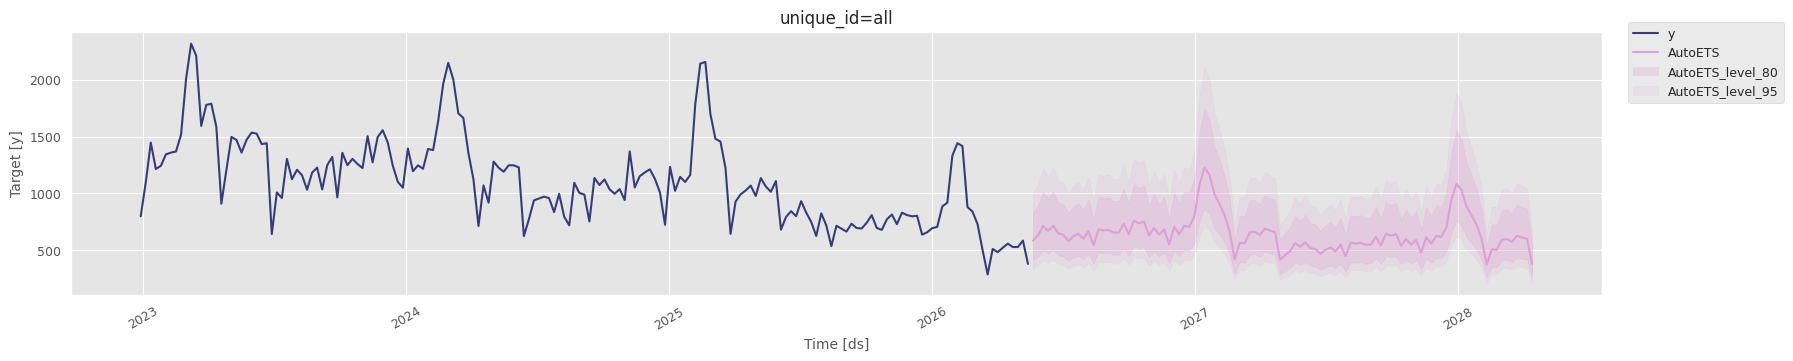

In [ ]:
# blambda = boxcox_lambda(base_df["total_weight"], "loglik", hijri_year_weeks)
blambda = 0

df = base_df.select(
    ds=pl.col("Date_depot"),
    y=pl.col("count").map_batches(lambda s: boxcox(s, blambda)),
    unique_id=pl.lit("all"),
)


sf = StatsForecast(
    models=[
        AutoETS(
            season_length=hijri_year_weeks,
            model="AAA",
            damped=True,
        ),
        AutoARIMA(
            season_length=hijri_year_weeks,
        ),
    ],
    freq="1w",
)

fc = sf.forecast(df=df, h=100, level=levels)

sf.plot(
    df.with_columns(
        pl.exclude("unique_id", "ds").map_batches(
            lambda s: inv_boxcox(s.to_numpy(), blambda)
        )
    ).to_pandas(),
    fc.with_columns(
        pl.exclude("unique_id", "ds").map_batches(
            lambda s: inv_boxcox(s.to_numpy(), blambda)
        )
    ).to_pandas(),
    level=levels,
)

In [139]:
(
    AutoARIMAProphet()
    .add_seasonality(name="hijri_yearly", period=hijri_year_weeks, fourier_order=5)
    .add_seasonality(
        name="gregorian_yearly", period=gregorian_year_weeks, fourier_order=5
    )
)

In [132]:
AutoETS().fit(df["y"].to_numpy())

AutoETS

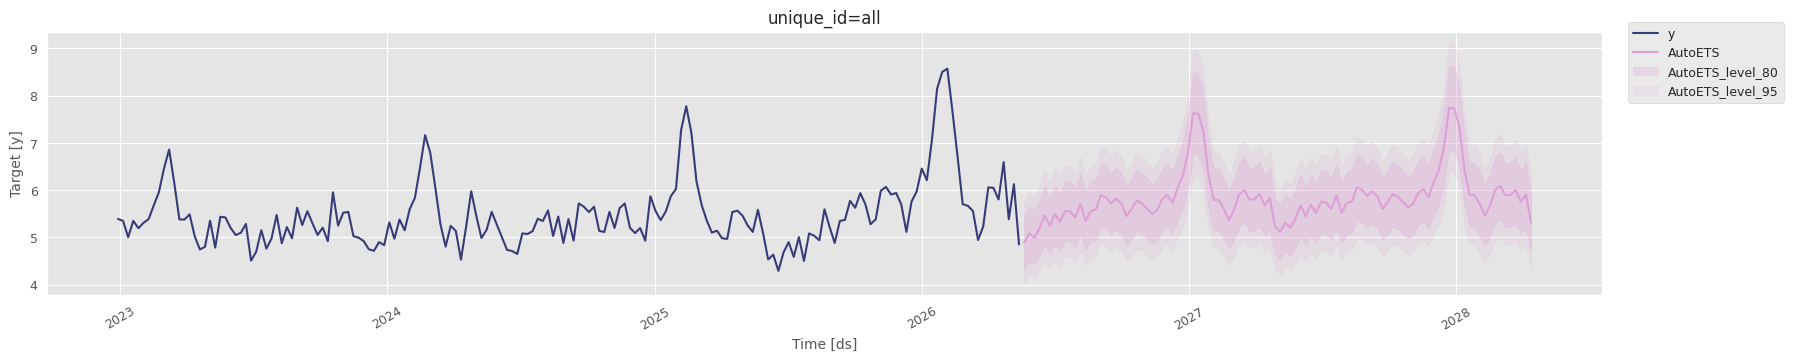

In [159]:
df = base_df.select(
    ds=pl.col("Date_depot"),
    y="mean_weight",
    unique_id=pl.lit("all"),
)

sf = StatsForecast(
    models=[
        AutoETS(
            season_length=hijri_year_weeks,
            model="MAA",
            damped=True,
        ),
        # AutoARIMA(
        #     season_length=hijri_year_weeks,
        #     seasonal=True,
        # ),
    ],
    freq="1w",
)
fc = sf.forecast(df=df, h=100, level=levels)
sf.plot(df, fc, level=levels)

In [ ]:
model = (
    AutoARIMAProphet(nmodels=1)
    .add_seasonality(name="hijri_yearly", period=hijri_year_weeks, fourier_order=5)
    .add_seasonality(
        name="gregorian_yearly", period=gregorian_year_weeks, fourier_order=5
    )
)
model.fit(df=df.to_pandas())
fc = model.predict()
sf.plot(df.to_pandas(), fc)

IndexError: index 1 is out of bounds for axis 0 with size 1

In [157]:
best_config = {
    "h": 10,
    "n_pool_kernel_size": [2, 2, 2],
    "n_freq_downsample": [24, 12, 1],
    "learning_rate": 0.00017565392237572106,
    "scaler_type": None,
    "max_steps": 1400.0,
    "batch_size": 256,
    "windows_batch_size": 1024,
    "loss": MAE(),
    "random_seed": 17,
    "input_size": 20,
    "step_size": 1,
    "valid_loss": MAE(),
}

In [ ]:
nf = NeuralForecast(
    models=[
        AutoNHITS(
            h=52,
        ),
        # NHITS(
        #     **{
        #         "h": 100,
        #         "n_pool_kernel_size": [2, 2, 2],
        #         "n_freq_downsample": [24, 12, 1],
        #         "learning_rate": 0.00017565392237572106,
        #         "scaler_type": None,
        #         "max_steps": 1400.0,
        #         "batch_size": 256,
        #         "windows_batch_size": 1024,
        #         "loss": MAE(),
        #         "random_seed": 17,
        #         "input_size": 20,
        #         "step_size": 1,
        #         "valid_loss": MAE(),
        #     }
        # ),
    ],
    freq="W",
)
nf.fit(df=df.to_pandas())
fc = nf.predict()
sf.plot(df.to_pandas(), fc)

(_train_tune pid=1986340) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=1986340) Seed set to 6
(_train_tune pid=1986340) GPU available: False, used: False
(_train_tune pid=1986340) TPU available: False, using: 0 TPU cores
(_train_tune pid=1986340) 
(_train_tune pid=1986340)   | Name         | Type          | Params | Mode 
(_train_tune pid=1986340) -------------------------------------------------------
(_train_tune pid=1986340) 0 | loss         | MAE           | 0      | train
(_train_tune pid=1986340) 1 | padder_train | ConstantPad1d | 0      | train
(_train_tune pid=1986340) 2 | scaler       | TemporalNorm  | 0      | train
(_train_tune pid=1986340) 3 | blocks       | ModuleList    | 3.0 M  | train
(_train_tune pid=1986340)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]                             


2026-06-09 12:19:49,458	ERROR tune_controller.py:1326 -- Trial task failed for trial _train_tune_bafe6_00000
Traceback (most recent call last):
  File "/home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/_private/client_mode_hook.py", line 107, in wrapper
    return func(*args, **kwargs)
  File "/home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/_private/worker.py", line 2980, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ~~~~~~~~~~~~~~~~~~^
        object_refs, timeout, use_

Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]


(_train_tune pid=1986457) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=1986457) Seed set to 15
(_train_tune pid=1986457) GPU available: False, used: False
(_train_tune pid=1986457) TPU available: False, using: 0 TPU cores
(_train_tune pid=1986457) 
(_train_tune pid=1986457)   | Name         | Type          | Params | Mode 
(_train_tune pid=1986457) -------------------------------------------------------
(_train_tune pid=1986457) 0 | loss         | MAE           | 0      | train
(_train_tune pid=1986457) 1 | padder_train | ConstantPad1d | 0      | train
(_train_tune pid=1986457) 2 | scaler       | TemporalNorm  | 0      | train
(_train_tune pid=1986457) 3 | blocks       | ModuleList    | 3.2 M  | train
(_train_tune pid=1986457

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=800.0` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

AttributeError: 'DataFrame' object has no attribute 'collect_schema'

Predicting: |          | 0/? [00:00<?, ?it/s]

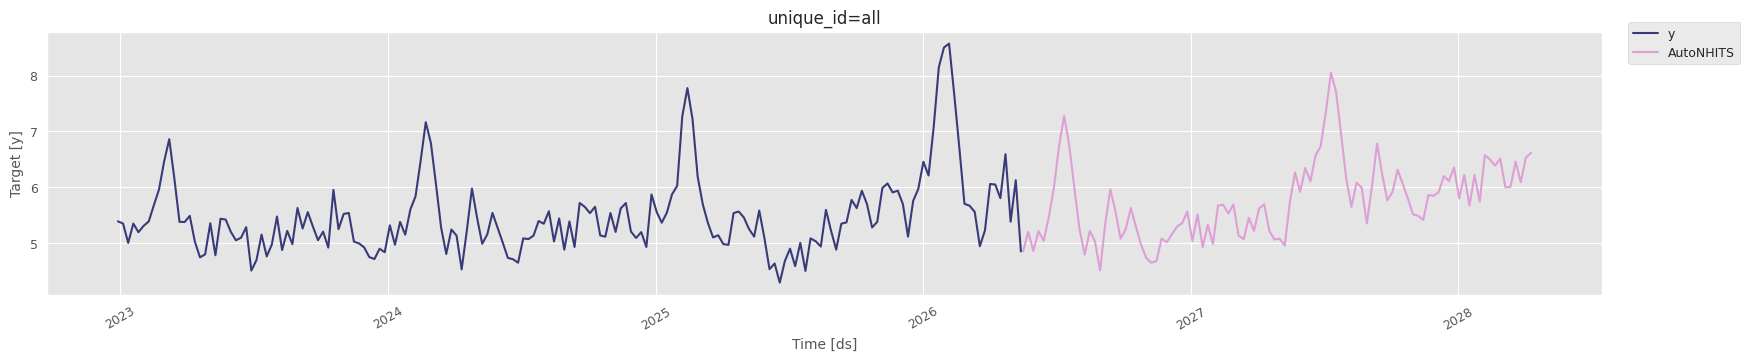

In [183]:
fc = nf.predict(h=100)
sf.plot(df.to_pandas(), fc)

In [ ]:
# auto_model = nf.models[0]
# best_config = auto_model.results.get_best_result().config

{'h': 10,
 'n_pool_kernel_size': [2, 2, 2],
 'n_freq_downsample': [24, 12, 1],
 'learning_rate': 0.00017565392237572106,
 'scaler_type': None,
 'max_steps': 1400.0,
 'batch_size': 256,
 'windows_batch_size': 1024,
 'loss': MAE(),
 'random_seed': 17,
 'input_size': 20,
 'step_size': 1,
 'valid_loss': MAE()}